In [1]:
import firedrake
import numpy as np
import pickle as pkl
from numpy import pi as π
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import firedrake
from firedrake import Constant, inner, sqrt, tr, grad, div, as_vector, exp,sym, as_vector, dx, ds, Mesh, Function, project, TransferManager
import meshpy, meshpy.geometry, meshpy.triangle
import irksome
from irksome import Dt
from scipy.signal import detrend
import copy
import matplotlib
import irksome
from irksome import Dt
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import pickle as pkl
import tqdm
import emcee
import corner
import itertools
import xarray
import dtscalibration
import glob
from rasterio.plot import show
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import os
import sys
from pyproj import Transformer
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scripts.AH_temp_funcs import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import shapefile as sf

import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask

from firedrake.checkpointing import DumbCheckpoint

from firedrake import *

### Import our homemade functions ###
import scripts.model_modules
from scripts.mesh_generating import *

%matplotlib widget

# 1. Load the necessary data

### 1.1 Borehole locations

In [2]:
### Load boreholes
borehole_locations = pd.read_csv('../Borehole_Locations/Borehole_locations_DTS.csv')
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)
transformed_x, transformed_y = transformer.transform(borehole_locations['E'], borehole_locations['S'])

### 1.2 LIMA image

In [3]:
with rasterio.open('../imagery/LIMA_virtual_Mosaic_15m.tif') as src1:
    image_data = src1.read()

### 1.3 GPS velocities

In [4]:
gps_velocities = pd.read_csv('../GPS_velocities/24-25_velocities-good.csv')
apres_points = pd.read_csv('../ApRES/apres_points.csv')

#### Outline of the area of the good dem

In [5]:
### Load the outline of the good dem

with rasterio.open('../Meshes/good_dem_outline/ian_bed_outline_raster_full.tif') as src_good_dem:
    good_dem_filter = src_good_dem.read(2)

# Do the meshing

In [6]:
upscale_factor_fine = 1/10
src_bed_fine_path = "../Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_bed.tif"
src_surf_fine_path = "../Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_surf.tif"
layer_num=5

In [7]:
mesh_fine = mesh_creator(src_bed_fine_path, src_surf_fine_path, resamp_factor=upscale_factor_fine, layers=layer_num)
x_src, y_src, z_src = SpatialCoordinate(mesh_fine)

pressure_space = firedrake.FunctionSpace(mesh_fine, "CG", 1)
velocity_space = firedrake.VectorFunctionSpace(mesh_fine, "CG", 3)
Y = velocity_space * pressure_space
flow = firedrake.Function(Y)

chk = DumbCheckpoint("../Saved_Models/fine_mesh_flow_80.0m_updated_viscosity", mode=FILE_READ)
chk.load(flow, name="fine_mesh_flow")

/opt/firedrake/firedrake/checkpointing.py:103: DeprecationWarning: DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.",


In [8]:
x_coords_mesh, y_coords_mesh = np.unique(mesh_fine.coordinates.dat.data_ro[:,0]), np.unique(mesh_fine.coordinates.dat.data_ro[:,1])
bed_of_mesh_coords = []
for x_co in x_coords_mesh:
    for y_co in y_coords_mesh:
        z_s =[]
        for x,y,z in zip(mesh_fine.coordinates.dat.data_ro[:,0], mesh_fine.coordinates.dat.data_ro[:,1], mesh_fine.coordinates.dat.data_ro[:,2]):

            if (x_co, y_co) == (x,y):
                z_s.append(z)

        z_min = np.array(z_s).min()

        bed_of_mesh_coords.append((x_co, y_co, z_min))

bed_of_mesh_coords_arr = np.array(bed_of_mesh_coords)



# Plot just on the mesh nodes at the bed

In [11]:
coords = []
u_vel = []
v_vel = []
w_vel = []

for x_bed_coord, y_bed_coord, z_bed_coord in bed_of_mesh_coords_arr:
    try:
        velocity_ms = flow.at((x_bed_coord, y_bed_coord, z_bed_coord))
        u_vel.append(velocity_ms[0][0])
        v_vel.append(velocity_ms[0][1])
        w_vel.append(velocity_ms[0][2])
        coords.append((x_bed_coord, y_bed_coord, z_bed_coord))
        print(velocity_ms)
    except:
        continue

(array([5.57674937e-25, 1.85458275e-25, 8.44604602e-27]), array(-982975.17927377))
(array([3.97632944e-24, 1.03591143e-24, 1.59235685e-25]), array(-962435.61216307))
(array([3.46977331e-24, 6.81197241e-25, 2.25724886e-25]), array(-961831.5186731))
(array([3.24364785e-24, 4.97958295e-25, 2.88511351e-25]), array(-948812.29449815))
(array([3.07071584e-24, 4.49403625e-25, 3.37448708e-25]), array(-939772.35632355))
(array([-2.37889070e-24, -4.44751040e-25, -2.99123568e-25]), array(-931666.90629361))
(array([-2.43863036e-25, -6.86447019e-26, -3.28144897e-26]), array(-925027.93788298))
(array([1.63605875e-24, 6.98774891e-25, 2.21338823e-25]), array(-922220.8970215))
(array([2.40641846e-24, 1.00084670e-24, 3.06443394e-25]), array(-922481.20440463))
(array([2.84645313e-24, 1.10640784e-24, 3.45916778e-25]), array(-923031.74859543))
(array([5.88241620e-24, 2.15002991e-24, 6.92894323e-25]), array(-922941.35070502))
(array([3.70978410e-24, 1.28037311e-24, 4.29152681e-25]), array(-923703.14178191))


/tmp/ipykernel_819225/1835756651.py:156: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(x_tick_labels)
/tmp/ipykernel_819225/1835756651.py:159: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_yticklabels(y_tick_labels)
/tmp/ipykernel_819225/1835756651.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


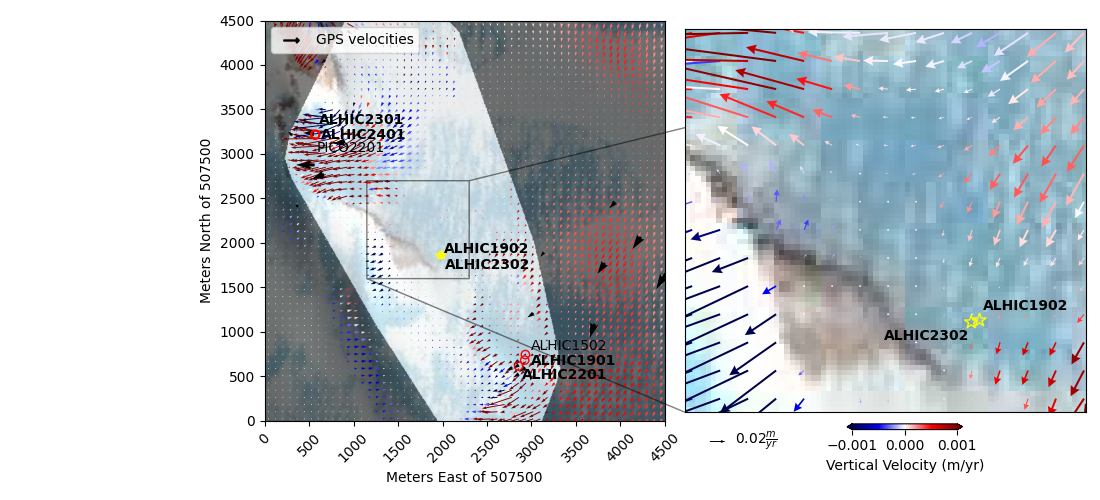

In [77]:
m_above_bed = 10

coords = []
u_vel = []
v_vel = []
w_vel = []

for x_bed_coord, y_bed_coord, z_bed_coord in bed_of_mesh_coords_arr:
    try:
        velocity_ms = flow.at((x_bed_coord, y_bed_coord, z_bed_coord+m_above_bed))
        u_vel.append(velocity_ms[0][0])
        v_vel.append(velocity_ms[0][1])
        w_vel.append(velocity_ms[0][2])
        coords.append((x_bed_coord, y_bed_coord, z_bed_coord))

    except:
        continue

fig, axes = plt.subplots(figsize=[11,5])


vel_cross = np.array([u_vel, v_vel, w_vel]).T
vel_cross_coords = np.asarray(coords)

norm_model = mcolors.Normalize(vmin=-0.001, vmax=0.001)
cmap = plt.cm.seismic
colors_model = cmap(norm_model(vel_cross[:,2]*spy))



show(image_data,ax=axes,transform=src1.transform)




Q = axes.quiver(vel_cross_coords[:,0], vel_cross_coords[:,1], vel_cross[:,0]*spy, vel_cross[:,1]*spy, 
                angles='xy', scale_units='xy', scale=None, color=colors_model)

axes.set_xlim([vel_cross_coords[:,0].min()-100, vel_cross_coords[:,0].max()+100])
axes.set_ylim([vel_cross_coords[:,1].min()-100, vel_cross_coords[:,1].max()+100])

# Colorbar
# sm = cm.ScalarMappable(cmap=cmap, norm=norm_model)
# sm.set_array([])  # Needed only to satisfy colorbar creation
# cbar = plt.colorbar(sm, ax=axes, fraction=0.026, pad=0.04)
# cbar.set_label('Vertical Velocity (m/yr)')

# import matplotlib.ticker as ticker
# cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))

### Colorbar for Model ###
cbar_ax = axes.inset_axes([.4, .04, 1, .3], xticks=[], yticks=[], facecolor="None") # Example: left, bottom, width, height
sm = cm.ScalarMappable(cmap=cmap, norm=norm_model)
cbar = plt.colorbar(sm, ax=cbar_ax, fraction=0.05, pad=0.04, location='bottom', extend='both')
cbar_ax.spines['left'].set_edgecolor('none')
cbar_ax.spines['right'].set_edgecolor('none')
cbar_ax.spines['top'].set_edgecolor('none')
cbar_ax.spines['bottom'].set_edgecolor('none')
cbar.set_label('Vertical Velocity (m/yr)')
import matplotlib.ticker as ticker
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))


# quiverkey_scale = .1
# quiverkey_scale_str = str(quiverkey_scale)




# qk = axes.quiverkey(Q, 1.06, 0.45, quiverkey_scale, quiverkey_scale_str+r'$\frac{m}{yr}$', labelpos='E', coordinates='axes', color='black')

colors_gps = cmap(norm_model(gps_velocities['w']))
axes.quiver(gps_velocities['x'], gps_velocities['y'], 
                gps_velocities['u'], gps_velocities['v'], 
                angles='xy', scale_units='xy', scale=None,
                #color=colors_gps
                )

show(good_dem_filter,ax=axes,transform=src_good_dem.transform,cmap='gray', alpha=0.5)

## Plotting and annotating boreholes ##

axes.scatter(transformed_x[0],transformed_y[0], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[0]['Core'], (transformed_x[0]+70,transformed_y[0]-50), weight='bold')

axes.scatter(transformed_x[1],transformed_y[1], marker='*',ec='yellow', fc="None")
axes.annotate(borehole_locations.iloc()[1]['Core'], (transformed_x[1]+20,transformed_y[1]+20), weight='bold')

axes.scatter(transformed_x[2],transformed_y[2], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[2]['Core'], (transformed_x[2]+20,transformed_y[2]+20), weight='bold')

axes.scatter(transformed_x[3],transformed_y[3], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[3]['Core'], (transformed_x[3]+40,transformed_y[3]-150), weight='bold')

axes.scatter(transformed_x[4],transformed_y[4], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[4]['Core'], (transformed_x[4]+40,transformed_y[4]+120), weight='bold')

axes.scatter(transformed_x[5],transformed_y[5], marker='*',ec='yellow', fc="None")
axes.annotate(borehole_locations.iloc()[5]['Core'], (transformed_x[5]+60,transformed_y[5]-150), weight='bold')

axes.scatter(transformed_x[6],transformed_y[6], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[6]['Core'], (transformed_x[6]+60,transformed_y[6]-50), weight='bold')

axes.scatter(transformed_x[7],transformed_y[7], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[7]['Core'], (transformed_x[7]+60,transformed_y[7]+50))

axes.scatter(transformed_x[8],transformed_y[8], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[8]['Core'], (transformed_x[8]+20,transformed_y[8]-200))

axes.scatter([], [], marker=r'$\longrightarrow$', color="black", s=120, label="GPS velocities")
axes.legend(loc='upper left')


axes.set_xlim([507500, 512000])
axes.set_ylim([-1.3555e6, -1.351e6])

axes.xaxis.set_tick_params(rotation=45)


# axes.set_title("Velocity "+str(m_above_bed)+' m Above Bed')
axins = axes.inset_axes(
    [1.05, 0, 1, 1],
    xticks=[], 
    yticks=[]
    )
show(image_data,ax=axins,transform=src1.transform)
Q_in = axins.quiver(vel_cross_coords[:,0], vel_cross_coords[:,1], vel_cross[:,0]*spy, vel_cross[:,1]*spy, 
                angles='xy', scale_units='xy', scale=2e-5, 
                width = 0.005,
                color=colors_model, 
                headwidth = 5,
                headlength = 5,
                minshaft = 2)

axins.scatter(transformed_x[1],transformed_y[1], marker='*',ec='yellow', fc="None",s=100)
axins.annotate(borehole_locations.iloc()[1]['Core'], (transformed_x[1]+10,transformed_y[1]+30), weight='bold')

axins.scatter(transformed_x[5],transformed_y[5], marker='*',ec='yellow', fc="None",s=100)
axins.annotate(borehole_locations.iloc()[5]['Core'], (transformed_x[5]-250,transformed_y[5]-50), weight='bold')

axins.set_xlim([508650, 509800])
axins.set_ylim([-1.3539e6, -1.3528e6])
axes.indicate_inset_zoom(axins, edgecolor="black")


quiverkey_scale = .02
quiverkey_scale_str = str(quiverkey_scale)

qk = axes.quiverkey(Q, 1.15, -0.05, quiverkey_scale, quiverkey_scale_str+r'$\frac{m}{yr}$', labelpos='E', coordinates='axes', color='black')

axes.set_xlabel('Meters East of '+axes.get_xticklabels()[0].get_text())
axes.set_ylabel('Meters North of '+axes.get_xticklabels()[0].get_text())


x_tick_labels = [int(float(item.get_text()) -  float(axes.get_xticklabels()[0].get_text())) for item in axes.get_xticklabels()]
axes.set_xticklabels(x_tick_labels)

y_tick_labels = [int(float(item.get_text().replace('−','-'))*1e6 -  float(axes.get_yticklabels()[0].get_text().replace('−','-'))*1e6) for item in axes.get_yticklabels()]
axes.set_yticklabels(y_tick_labels)


plt.tight_layout()
# plt.savefig('Figures/fig1_updated_80m_subplot.eps', dpi=600, bbox_inches='tight', format='eps', transparent=True)
# plt.savefig('Figures/fig1_updated_80m_subplot.png', dpi=600, bbox_inches='tight', format='png', transparent=False)

# Plot at an individual coordinate

Get the node closest to where 1902 is

In [ ]:
ah1902_x, ah1902_y = transformer.transform(borehole_locations.iloc[1]['E'], borehole_locations.iloc[1]['S'])

In [ ]:
ah_1902_slice_loc = np.argmin(np.sqrt((bed_of_mesh_coords_arr[:,0]-ah1902_x)**2 + (bed_of_mesh_coords_arr[:,1]-ah1902_y)**2))

In [31]:
x_coords_mesh, y_coords_mesh = np.unique(mesh_fine.coordinates.dat.data_ro[:,0]), np.unique(mesh_fine.coordinates.dat.data_ro[:,1])

profile_coords = []
x_interest, y_interest = np.float64(bed_of_mesh_coords_arr[:,0][ah_1902_slice_loc]), np.float64(bed_of_mesh_coords_arr[:,1][ah_1902_slice_loc])

u_vel = []
v_vel = []
w_vel = []

for x,y,z in zip(mesh_fine.coordinates.dat.data_ro[:,0], mesh_fine.coordinates.dat.data_ro[:,1], mesh_fine.coordinates.dat.data_ro[:,2]):

    if (x_interest, y_interest) == (x,y):
        
        profile_coords.append((x_interest, y_interest, z))
        velocity_ms = flow.at((x_interest, y_interest, z))
        u_vel.append(velocity_ms[0][0])
        v_vel.append(velocity_ms[0][1])
        w_vel.append(velocity_ms[0][2])


profile_coords = np.array(profile_coords)


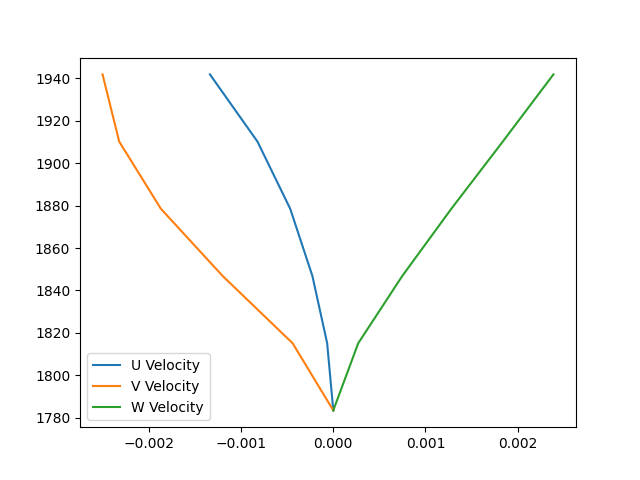

In [33]:
fig,ax = plt.subplots()
ax.plot(np.array(u_vel)*spy, profile_coords[:,-1], label='U Velocity')
ax.plot(np.array(v_vel)*spy, profile_coords[:,-1], label='V Velocity')
ax.plot(np.array(w_vel)*spy, profile_coords[:,-1], label='W Velocity')
ax.legend()

# Plot this in a flow line along the mesh nodes

In [64]:

flowline_surf = pd.read_csv('../flowlines/manual_flowlines/csv/ALHIC2302_surface_rema_100m.csv')
flowline_bed = pd.read_csv('../flowlines/manual_flowlines/csv/ALHIC2302_bed_merged_100m.csv')
flowline_xs = flowline_surf['E']
flowline_ys = flowline_surf['N']
flowline_bed_elev = flowline_bed['Elev']
flowline_surf_elev = flowline_surf['Elev']
flowline_distance = flowline_surf['Distance']


flowline_surf = pd.read_csv('../flowlines/old_ice_flowlines/ALHIC1902_R2_surface_nunatak_test_100m_test_case_3.csv')
flowline_bed = pd.read_csv('../flowlines/old_ice_flowlines/ALHIC1902_R2_bed_nunatak_test_100m_test_case_3.csv')
flowline_xs = flowline_surf['E']
flowline_ys = flowline_surf['N']
flowline_bed_elev = flowline_bed['Elev']
flowline_surf_elev = flowline_surf['Elev']
flowline_distance = flowline_surf['Distance']

In [65]:
all_coords = []

all_u_vel = []
all_v_vel = []
all_w_vel = []
all_distance_list = []
distance = 0
for n, (flowline_x, flowline_y) in enumerate(zip(flowline_xs, flowline_ys)):
    flowline_slice_loc = np.argmin(np.sqrt((bed_of_mesh_coords_arr[:,0]-flowline_x)**2 + (bed_of_mesh_coords_arr[:,1]-flowline_y)**2))

    profile_coords = []
    x_interest, y_interest = np.float64(bed_of_mesh_coords_arr[:,0][flowline_slice_loc]), np.float64(bed_of_mesh_coords_arr[:,1][flowline_slice_loc])

    u_vel = []
    v_vel = []
    w_vel = []


    distance_list = []

    if n > 0:
        distance += np.sqrt((flowline_x-flowline_xs[n-1])**2 + (flowline_y-flowline_ys[n-1])**2)

    for x,y,z in zip(mesh_fine.coordinates.dat.data_ro[:,0], mesh_fine.coordinates.dat.data_ro[:,1], mesh_fine.coordinates.dat.data_ro[:,2]):

        if (x_interest, y_interest) == (x,y):
            
            profile_coords.append((x_interest, y_interest, z))
            velocity_ms = flow.at((x_interest, y_interest, z))
            u_vel.append(velocity_ms[0][0])
            v_vel.append(velocity_ms[0][1])
            w_vel.append(velocity_ms[0][2])
            distance_list.append(distance)

    profile_coords = np.array(profile_coords)
    all_coords.append(profile_coords)
    all_u_vel.append(u_vel)
    all_v_vel.append(v_vel)
    all_w_vel.append(w_vel)
    all_distance_list.append(distance_list)

In [66]:
all_u_vel_arr = np.array(all_u_vel)*spy
all_v_vel_arr = np.array(all_v_vel)*spy
all_w_vel_arr = np.array(all_w_vel)*spy
all_coords_arr = np.array(all_coords)
all_distance_list_arr = np.array(all_distance_list)

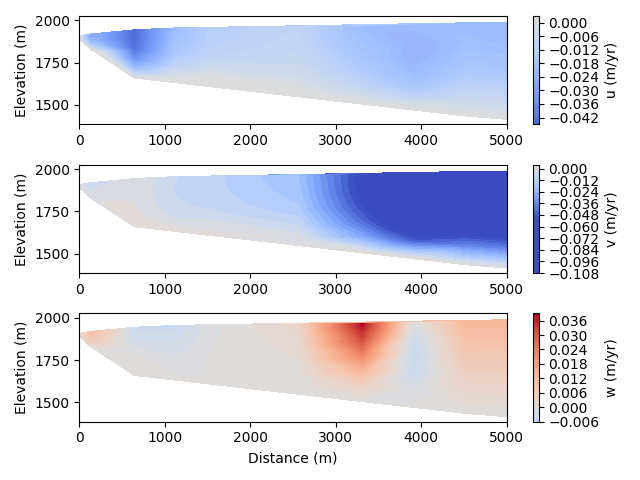

In [79]:
fig, axes = plt.subplots(3, 1)
vm = np.abs(all_u_vel_arr.max()+.05)
cu = axes[0].tricontourf(all_distance_list_arr.flatten(), all_coords_arr[:,:,2].flatten(), all_u_vel_arr.flatten(), levels=30,vmin=-vm,vmax=vm, cmap='coolwarm')
vm = np.abs(all_v_vel_arr.max()+.05)
cv = axes[1].tricontourf(all_distance_list_arr.flatten(), all_coords_arr[:,:,2].flatten(), all_v_vel_arr.flatten(), levels=30,vmin=-vm,vmax=vm, cmap='coolwarm')
vm = np.abs(all_w_vel_arr.max())
cw = axes[2].tricontourf(all_distance_list_arr.flatten(), all_coords_arr[:,:,2].flatten(), all_w_vel_arr.flatten(), levels=30,vmin=-vm,vmax=vm, cmap='coolwarm')

# Colorbars
fig.colorbar(cu, ax=axes[0], label='u (m/yr)')
fig.colorbar(cv, ax=axes[1], label='v (m/yr)')
fig.colorbar(cw, ax=axes[2], label='w (m/yr)')

axes[0].set_ylabel('Elevation (m)')
axes[1].set_ylabel('Elevation (m)')
axes[2].set_ylabel('Elevation (m)')

axes[2].set_xlabel('Distance (m)')

axes[0].set_xlim([0,5000])
axes[1].set_xlim([0,5000])
axes[2].set_xlim([0,5000])

plt.tight_layout()



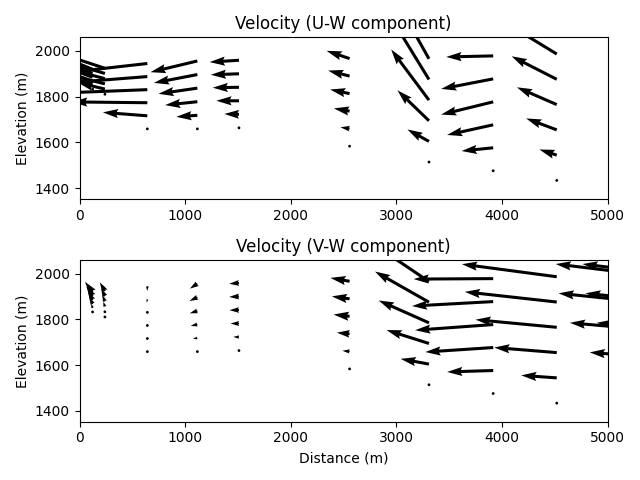

In [80]:
fig, axes = plt.subplots(2, 1)

axes[0].quiver(all_distance_list_arr.flatten(), all_coords_arr[:,:,2].flatten(), all_u_vel_arr.flatten(), all_w_vel_arr.flatten())
axes[1].quiver(all_distance_list_arr.flatten(), all_coords_arr[:,:,2].flatten(), all_v_vel_arr.flatten(), all_w_vel_arr.flatten())

axes[0].set_xlim([0,5000])
axes[1].set_xlim([0,5000])

axes[0].set_ylabel('Elevation (m)')
axes[1].set_ylabel('Elevation (m)')

axes[1].set_xlabel('Distance (m)')

axes[0].set_title('Velocity (U-W component)')
axes[1].set_title('Velocity (V-W component)')
plt.tight_layout()

# Plot figure 3 again

In [ ]:
ah1902_x, ah1902_y = transformer.transform(borehole_locations.iloc[1]['E'], borehole_locations.iloc[1]['S'])

In [102]:
meters_above_bed = 10

bore_dict = {}
for i in borehole_locations.iloc():

    x_utm, y_utm = transformer.transform(i['E'], i['S'])
    core_age = i['oldest ice']

    slice_loc = np.argmin(np.sqrt((bed_of_mesh_coords_arr[:,0]-x_utm)**2 + (bed_of_mesh_coords_arr[:,1]-y_utm)**2))
    

    
    x_interest, y_interest = np.float64(bed_of_mesh_coords_arr[:,0][slice_loc]), np.float64(bed_of_mesh_coords_arr[:,1][slice_loc])

    z_s = []
    for x,y,z in zip(mesh_fine.coordinates.dat.data_ro[:,0], mesh_fine.coordinates.dat.data_ro[:,1], mesh_fine.coordinates.dat.data_ro[:,2]):

        if (x_interest, y_interest) == (x,y):
            
            z_s.append(z)
    
    z_bed = np.array(z_s).min()

    try:
        velocity_ms = flow.at((x_interest, y_interest, z_bed+meters_above_bed))
        speed = np.sqrt(velocity_ms[0][0]**2+velocity_ms[0][1]**2+velocity_ms[0][2]**2)
    except:
        speed = np.nan
    bore_dict[i['Core']] = [x_utm, y_utm, core_age, speed]
    
bore_dict_arr = np.array(list(bore_dict.values()))

Text(0.5, 0, 'Age (Mya)')

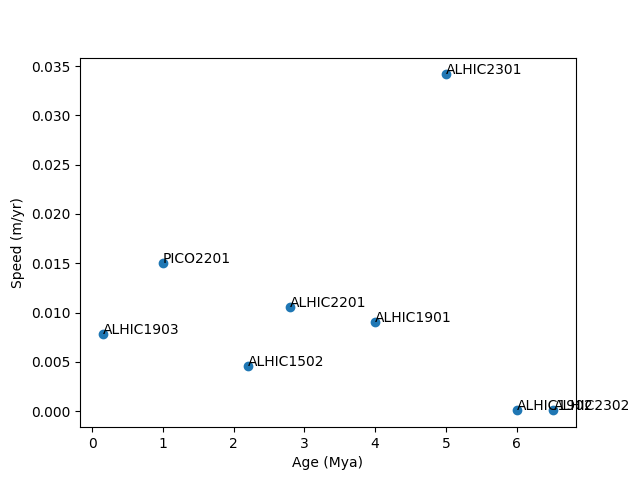

In [113]:
fig,ax = plt.subplots()

ax.scatter(bore_dict_arr[:,2]/1e6,bore_dict_arr[:,3]*spy)

for i, txt in enumerate(bore_dict):
    try:
        ax.annotate(txt, (bore_dict[txt][2]/1e6, bore_dict[txt][3]*spy))
    except:
        continue

ax.set_ylabel('Speed (m/yr)')
ax.set_xlabel('Age (Mya)')